# Import

In [4]:
"""
Progetto di classificazione delle specie di uccelli CUB-200-2011. Questo script
implementa approcci di transfer learning e CNN personalizzati per una
classificazione dettagliata degli uccelli.
"""

import re
import os
import random
import math
import time

import pandas as pd
import numpy as np
import collections
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from PIL import Image
from math import pi

import keras
import tensorflow as tf
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import (classification_report, roc_curve, auc,
                            precision_recall_curve, average_precision_score,
                            accuracy_score, f1_score, precision_recall_fscore_support,
                            top_k_accuracy_score)
from sklearn.calibration import calibration_curve, CalibratedClassifierCV
from sklearn.svm import LinearSVC
!pip install keras-tuner
import keras_tuner as kt

keras.utils.set_random_seed(42)

# Dataset class

In [5]:
class DatasetManager:
    """
    Gestisce il caricamento, la pre-elaborazione e la suddivisione del set di
    dati CUB-200-2011.
    """
    def __init__(self, base_path="CUB_200_2011"):
        self.base_path = base_path
        self.df_combined = None
        self.train_data = None
        self.val_data = None
        self.test_data = None
        self.num_classes = 200

    def download_dataset(self):
        """
        Scarica ed estrae il set di dati CUB-200-2011
        """
        print("Downloading CUB-200-2011 dataset...")
        os.system("wget https://data.caltech.edu/records/65de6-vp158/files/CUB_200_2011.tgz")
        os.system("tar -xvzf CUB_200_2011.tgz")
        print("Dataset downloaded and extracted successfully!")

    def load_metadata(self):
        """
        Carica e unisci tutti i file di metadati dal set di dati CUB
        """
        df_classes = pd.read_csv(
            f"{self.base_path}/classes.txt",
            sep=" ",
            header=None,
            names=["class_id", "class_name_raw"]
        )
        df_classes['class_id'] = df_classes['class_id'] - 1

        df_images_path = pd.read_csv(
            f"{self.base_path}/images.txt",
            sep=" ",
            header=None,
            names=["image_id", "image_path"]
        )

        df_class_to_images = pd.read_csv(
            f"{self.base_path}/image_class_labels.txt",
            sep=" ",
            header=None,
            names=["image_id", "class_id"]
        )
        df_class_to_images['class_id'] = df_class_to_images['class_id'] - 1

        df_train_test_split = pd.read_csv(
            f"{self.base_path}/train_test_split.txt",
            sep=" ",
            header=None,
            names=["image_id", "is_train"]
        )

        print(f"Number of classes: {df_classes.shape}")
        print(f"Number of images: {df_images_path.shape}")
        print(f"Class-image correspondence: {df_class_to_images.shape}")
        print(f"Train test split information: {df_train_test_split.shape}")

        # Controlla la presenza di valori nulli
        print(f"Classes contain null values: {df_classes.isnull().values.any()}")
        print(f"Images contain null values: {df_images_path.isnull().values.any()}")
        print(f"Class-image mapping contains null values: {df_class_to_images.isnull().values.any()}")
        print(f"Train-test split contains null values: {df_train_test_split.isnull().values.any()}")

        # Unisce tutti i dataframe
        merged_temp = pd.merge(
            pd.merge(df_class_to_images, df_train_test_split, on="image_id", how="left"),
            df_images_path,
            on='image_id',
            how='left'
        )

        self.df_combined = pd.merge(merged_temp, df_classes, on='class_id', how='inner')
        self.df_combined['class_name'] = self.df_combined['class_name_raw'].str.split('.').str[-1]
        self.df_combined['image_path'] = f"{self.base_path}/images/" + self.df_combined['image_path']

        print("Metadata loaded and merged successfully!")
        print(self.df_combined.head())

        return self.df_combined

    def split_dataset(self, val_size=0.15, random_state=42):
        """
        Suddivide il dataset in set di addestramento, validazione e test
        """
        print("Separazione dataset")

        self.train_data = self.df_combined[self.df_combined['is_train'] == 1]
        self.test_data = self.df_combined[self.df_combined['is_train'] == 0]

        train_labels = self.train_data['class_id']
        self.train_data, self.val_data = train_test_split(
            self.train_data,
            test_size=val_size,
            random_state=random_state,
            stratify=train_labels
        )

        print(f"Train instances: {self.train_data.shape}")
        print(f"Validation instances: {self.val_data.shape}")
        print(f"Test instances: {self.test_data.shape}")

    def visualize_dataset(self):
       """
       Esegue un'analisi esplorativa dei dati: Distribuzione delle classi)
       """
       plt.style.use('ggplot')
       # Distribuzione delle classi
       class_counts = self.df_combined['class_name'].value_counts().sort_index()
       plt.figure(figsize=(15, 5))
       plt.bar(class_counts.index, class_counts.values, color='skyblue', edgecolor='black')
       plt.title('Class Distribution', fontsize=14)
       plt.xlabel('Classes', fontsize=12)
       plt.ylabel('Count', fontsize=12)
       plt.xticks([])
       plt.show()

       #Varianza inter-classe
       target_keywords = ['Tree_Sparrow', 'Savannah_Sparrow']
       found_classes = []
       all_classes = self.df_combined['class_name'].unique()

       for keyword in target_keywords:
           match = [c for c in all_classes if keyword in c]
           if match:
               found_classes.append(match[0])

       plt.figure(figsize=(10, 5))
       plt.suptitle("Inter-class", fontsize=18)

       for i, cls_name in enumerate(found_classes):
            row = self.df_combined[self.df_combined['class_name'] == cls_name].sample(1).iloc[0]
            img_path = row['image_path']
            clean_name = cls_name.split('.')[-1].replace('_', ' ')
            try:
               img = Image.open(img_path)
               plt.subplot(1, 2, i + 1)
               plt.imshow(img)
               plt.title(clean_name, fontsize=16, fontweight='bold', color='#333333')
               plt.axis('off')
            except Exception as e:
               print(f"Error loading {img_path}: {e}")
       plt.tight_layout()
       plt.show()

    def create_tf_datasets(self, batch_size=64):
        """
        Crea dataset TensorFlow con pre-processing
        """
        # Ottiene i percorsi delle immagini
        img_path_train = self.train_data['image_path'].astype(str).to_list()
        img_path_val = self.val_data['image_path'].astype(str).to_list()
        img_path_test = self.test_data['image_path'].astype(str).to_list()

        # Ottiene le etichette (codifica one-hot)
        labels_train = keras.utils.to_categorical(self.train_data['class_id'], self.num_classes)
        labels_val = keras.utils.to_categorical(self.val_data['class_id'], self.num_classes)
        labels_test = keras.utils.to_categorical(self.test_data['class_id'], self.num_classes)

        train_dataset = tf.data.Dataset.from_tensor_slices((img_path_train, labels_train))
        val_dataset = tf.data.Dataset.from_tensor_slices((img_path_val, labels_val))
        test_dataset = tf.data.Dataset.from_tensor_slices((img_path_test, labels_test))

        # Applica il pre-processing
        train_dataset = train_dataset.map(self._process_path, num_parallel_calls=tf.data.AUTOTUNE)
        val_dataset = val_dataset.map(self._process_path, num_parallel_calls=tf.data.AUTOTUNE)
        test_dataset = test_dataset.map(self._process_path, num_parallel_calls=tf.data.AUTOTUNE)

        train_dataset = train_dataset.batch(batch_size)
        val_dataset = val_dataset.batch(batch_size)
        test_dataset = test_dataset.batch(batch_size)

        train_dataset = train_dataset.prefetch(tf.data.AUTOTUNE)
        val_dataset = val_dataset.prefetch(tf.data.AUTOTUNE)
        test_dataset = test_dataset.prefetch(tf.data.AUTOTUNE)

        return train_dataset, val_dataset, test_dataset

    @staticmethod
    def _process_path(file_path, label):
        """
        Carica le immagini, le ridimensiona e ritaglia a 224x224
        """
        img = tf.io.read_file(file_path)
        img = tf.image.decode_jpeg(img, channels=3)
        shape = tf.shape(img)
        height, width = shape[0], shape[1]

        min_side = tf.minimum(height, width)
        scale = 256.0 / tf.cast(min_side, tf.float32)
        new_height = tf.cast(tf.cast(height, tf.float32) * scale, tf.int32)
        new_width = tf.cast(tf.cast(width, tf.float32) * scale, tf.int32)

        img = tf.image.resize(img, [new_height, new_width])
        img = tf.image.resize_with_crop_or_pad(img, 224, 224)
        img = tf.cast(img, tf.float32)

        return img, label

# Augmentation

In [6]:
class RandomApply(keras.layers.Layer):
    """
    Layer personalizzato per applicare l'augmentation in modo probabilistico
    Estende keras.layers.Layer
    """
    def __init__(self, layer, probability=0.5, **kwargs):
        super().__init__(**kwargs)
        self.layer = layer
        self.probability = probability

    def call(self, inputs, training=True):
        """
        Applica il layer di augmentation con la probabilità specificata
        durante l'addestramento
        """
        if not training:
            return inputs
        return tf.cond(
            tf.random.uniform([], 0, 1) < self.probability,
            lambda: self.layer(inputs),
            lambda: inputs
        )

class AugmentationPipeline:
    """
    Gestisce la pipeline di aumentation per l'addestramento
    """
    @staticmethod
    def get_augmentation():
        # augmentation forte
        strong_transforms = keras.Sequential([
            keras.layers.RandomRotation(0.1, fill_mode="reflect"),
            keras.layers.RandomShear(0.40, fill_mode="reflect"),
            keras.layers.RandomZoom(height_factor=(-0.3, 0.2), fill_mode="reflect"),
            keras.layers.RandomTranslation(height_factor=0.15, width_factor=0.15, fill_mode="reflect"),
            keras.layers.RandomContrast(0.2),
            keras.layers.RandomBrightness(0.2)
        ])

        return keras.Sequential([
            keras.layers.RandomFlip("horizontal"),
            RandomApply(strong_transforms, probability=0.7)
        ], name="Probabilistic_Augmentation")

    @staticmethod
    def show_augmented_samples(dataset, num_samples=9):
        """
        Mostra una griglia di immagini a cui è stata applicata la augmentation
        """
        augmentation = AugmentationPipeline.get_augmentation()
        images, _ = next(iter(dataset.take(1)))
        cols = 3
        rows = math.ceil(num_samples / cols)

        plt.figure(figsize=(8, 2 * rows))

        for i in range(num_samples):
            img_tensor = tf.expand_dims(images[i], 0)
            aug_img = augmentation(img_tensor, training=True)

            plt.subplot(rows, cols, i + 1)
            plt.imshow(aug_img[0].numpy().astype("uint8"))
            plt.title(f"Augmented {i+1}")
            plt.axis("off")

        plt.tight_layout()
        plt.show()

# Models class

In [8]:
class TransferLearningModel:
    """
    Classe base per modelli di transfer learning
    Definisce funzioni comuni per l'addestramento e il fine-tuning di modelli
    """
    def __init__(self, num_classes, input_shape=(224, 224, 3)):
        self.num_classes = num_classes
        self.input_shape = input_shape
        self.base_model = None
        self.model = None
        self.history_head = None
        self.history_fine = None

    def _get_augmentation(self):
        """
        Ottiene la pipeline di data augmentation
        """
        return AugmentationPipeline.get_augmentation()

    def compile_for_phase(self, learning_rate, weight_decay, epochs,
                          batches_per_epoch, momentum=0.9, alpha=0.0):
        """
        Compila il modello con i parametri specifici passati
        Utilizza l'ottimizzatore SGD con momento di Nesterov e uno
        scheduler per il learning rate
        """
        lr_schedule = keras.optimizers.schedules.CosineDecay(
            initial_learning_rate=learning_rate,
            decay_steps=epochs * batches_per_epoch,
            alpha=alpha
        )

        self.model.compile(
            optimizer=keras.optimizers.SGD(
                learning_rate=lr_schedule,
                momentum=momentum,
                weight_decay=weight_decay,
                nesterov=True
            ),
            loss=keras.losses.CategoricalCrossentropy(),
            metrics=['accuracy', keras.metrics.TopKCategoricalAccuracy(k=5, name='top5_acc')]
        )

    def train_head(self, train_ds, val_ds, epochs=5, lr=0.01, weight_decay=5e-4):
        """
        Addestra solo la testa di classificazione, usa i valori passati
        """
        print("\n Training della testa")
        batches_per_epoch = len(train_ds)

        self.compile_for_phase(
            learning_rate=lr,
            weight_decay=weight_decay,
            epochs=epochs,
            batches_per_epoch=batches_per_epoch
        )

        self.history_head = self.model.fit(
            train_ds,
            epochs=epochs,
            validation_data=val_ds
        )

    def plot_results(self, model_name=None):
        """
        Permette di mostrare le curve di accuracy e loss
        La linea verticale indica il passaggio dall'addestramento della testa al fine-tuning
        """
        h1, h2 = self.history_head, self.history_fine

        acc = h1.history['accuracy'] + h2.history['accuracy']
        val_acc = h1.history['val_accuracy'] + h2.history['val_accuracy']
        loss = h1.history['loss'] + h2.history['loss']
        val_loss = h1.history['val_loss'] + h2.history['val_loss']

        epochs_range = range(len(acc))
        plt.figure(figsize=(12, 5))

        if model_name:
            plt.suptitle(f"{model_name}", fontsize=16)

        # Grafico dell'accuracy
        plt.subplot(1, 2, 1)
        plt.plot(epochs_range, acc, label='Train Accuracy')
        plt.plot(epochs_range, val_acc, label='Val Accuracy')
        plt.axvline(x=len(h1.history['accuracy'])-1, color='g', linestyle='--', label='Fine-tuning starts')
        plt.legend()
        plt.title('Accuracy')

        # Grafico della loss
        plt.subplot(1, 2, 2)
        plt.plot(epochs_range, loss, label='Train Loss')
        plt.plot(epochs_range, val_loss, label='Val Loss')
        plt.axvline(x=len(h1.history['accuracy'])-1, color='g', linestyle='--', label='Fine-tuning starts')
        plt.legend()
        plt.title('Loss')
        plt.show()

    def get_history(self):
        """
        history da entrambe le fasi
        """
        return self.history_head, self.history_fine

    def get_weights(self):
      """
      Ottiene i pesi del modello
      """
      return self.model.get_weights()

    def set_weights(self, weights):
      """
      Imposta i pesi del modello
      """
      self.model.set_weights(weights)

    def evaluate(self, test_ds):
      """
      Restituisce la lista di metrice di valutazione
      """
      return self.model.evaluate(test_ds)

## MobileNetV2 class

In [9]:
class MobileNetV2Model(TransferLearningModel):
    """
    Implementazione del transfer learning con MobileNetV2
    """
    def build_model(self):
        """
        Costruisce il modello MobileNetV2 con una testa di classificazione personalizzata
        Utilizza Sequential.
        """

        self.base_model = keras.applications.MobileNetV2(
            include_top=False,
            weights="imagenet",
            input_shape=self.input_shape,
            pooling='avg'
        )
        self.base_model.trainable = False

        self.model = keras.Sequential([
            keras.Input(shape=self.input_shape),
            self._get_augmentation(),
            keras.layers.Rescaling(scale=1./127.5, offset=-1),
            self.base_model,
            keras.layers.Dropout(0.5),
            keras.layers.Dense(256, activation='relu', kernel_initializer='he_normal'),
            keras.layers.BatchNormalization(),
            keras.layers.Dropout(0.5),
            keras.layers.Dense(self.num_classes, activation='softmax')
        ], name='MobileNetV2_Classifier')

    def fine_tune(self, train_ds, val_ds, start_block=15, epochs=100):
        """
        Esegue il fine-tuning del modello a partire dal blocco specificato in poi
        """
        print(f"\n Fine-tuning dal blocco {start_block}")

        self.base_model.trainable = True
        for layer in self.base_model.layers:
            if 'block_' in layer.name:
                match = re.search(r'block_(\d+)', layer.name)

                if match:
                    block_number = int(match.group(1))
                    if block_number >= start_block and not isinstance(layer, keras.layers.BatchNormalization):
                        layer.trainable = True
                    else:
                        layer.trainable = False
                else:
                    layer.trainable = False
            else:
                layer.trainable = False

        batches_per_epoch = len(train_ds)
        self.compile_for_phase(
            learning_rate=0.001,
            weight_decay=1e-3,
            epochs=epochs,
            batches_per_epoch=batches_per_epoch
        )

        early_stop = keras.callbacks.EarlyStopping(
            monitor='val_loss',
            patience=10,
            restore_best_weights=True
        )

        # Continua l'addestramento da dove è terminato l'addestramento della testa
        initial_epoch = self.history_head.epoch[-1] + 1
        self.history_fine = self.model.fit(
            train_ds,
            epochs=epochs + initial_epoch,
            initial_epoch=initial_epoch,
            validation_data=val_ds,
            callbacks=[early_stop]
        )

## ResNet50V2 class

In [11]:
class ResNet50V2Model(TransferLearningModel):
    """
    Implementazione del transfer learning con ResNet50V2.
    """
    def build_model(self):
      """
      Costruisce il modello ResNet50V2 con una testa di classificazione personalizzata
      Utilizza Sequential.
      """
      self.base_model = keras.applications.ResNet50V2(
            include_top=False,
            weights="imagenet",
            input_shape=self.input_shape,
            pooling='avg'
        )
      self.base_model.trainable = False

      self.model = keras.Sequential([
            keras.Input(shape=self.input_shape),
            self._get_augmentation(),
            keras.layers.Rescaling(scale=1./127.5, offset=-1),
            self.base_model,
            keras.layers.Dropout(0.6),
            keras.layers.Dense(256, activation='relu', kernel_initializer='he_normal'),
            keras.layers.BatchNormalization(),
            keras.layers.Dropout(0.5),
            keras.layers.Dense(self.num_classes, activation='softmax')
      ], name='ResNet50V2_Classifier')

    def fine_tune(self, train_ds, val_ds, start_stage="conv5", epochs=100):
        """
        Esegue il fine-tuning del modello a partire dal layer specificato.
        """
        print(f"\n Fine-tuning dallo stage {start_stage}")

        self.base_model.trainable = True
        for layer in self.base_model.layers:
            if layer.name.startswith(start_stage) and not isinstance(layer, keras.layers.BatchNormalization):
                layer.trainable = True
            else:
                layer.trainable = False

        batches_per_epoch = len(train_ds)
        self.compile_for_phase(
            learning_rate=0.0005,
            weight_decay=5e-3,
            epochs=epochs,
            batches_per_epoch=batches_per_epoch
        )

        early_stop = keras.callbacks.EarlyStopping(
            monitor='val_loss',
            patience=10,
            restore_best_weights=True
        )

        initial_epoch = self.history_head.epoch[-1] + 1
        self.history_fine = self.model.fit(
            train_ds,
            epochs=epochs + initial_epoch,
            initial_epoch=initial_epoch,
            validation_data=val_ds,
            callbacks=[early_stop]
        )

## InceptionV3 class

In [13]:
class InceptionV3Model(TransferLearningModel):
    """
    Implementazione del transfer learning con InceptionV3.
    A differenza degli altri modelli richiede un input di 299x299.
    """
    def __init__(self, num_classes, input_shape=(224, 224, 3)):
      """
      Il modello ridimensiona internamente a 299x299
      """
      super().__init__(num_classes, input_shape)

    def build_model(self):
        """
        Costruisce il modello InceptionV3 con una testa di classificazione personalizzata
        Utilizza Sequential.
        """
        self.base_model = keras.applications.InceptionV3(
            include_top=False,
            weights="imagenet",
            input_shape=(299, 299, 3),
            pooling='avg'
        )
        self.base_model.trainable = False

        layers = [keras.Input(shape=self.input_shape)]

        if self.input_shape[:2] != (299, 299):
            layers.append(keras.layers.Resizing(299, 299))

        layers.extend([
            self._get_augmentation(),
            keras.layers.Rescaling(scale=1./127.5, offset=-1),  # Normalize to [-1, 1]
            self.base_model,
            keras.layers.Dropout(0.5),
            keras.layers.Dense(256, activation='relu', kernel_initializer='he_normal'),
            keras.layers.BatchNormalization(),
            keras.layers.Dropout(0.5),
            keras.layers.Dense(self.num_classes, activation='softmax')
        ])

        self.model = keras.Sequential(layers, name='InceptionV3_Classifier')

    def fine_tune(self, train_ds, val_ds, fine_tune_at='mixed6', epochs=100, alpha=0.05):
        """
        Esegue il fine-tuning del modello a partire dal livello specificato in poi
        """
        print(f"\n Fine-tuning dal layer {fine_tune_at}")

        self.base_model.trainable = True
        layer_names = [layer.name for layer in self.base_model.layers]

        fine_tune_at_index = layer_names.index(fine_tune_at)

        for i, layer in enumerate(self.base_model.layers):
            if i < fine_tune_at_index or isinstance(layer, keras.layers.BatchNormalization):
                layer.trainable = False
            else:
                layer.trainable = True

        batches_per_epoch = len(train_ds)
        self.compile_for_phase(
            learning_rate=0.001,
            weight_decay=1e-3,
            epochs=epochs,
            batches_per_epoch=batches_per_epoch,
            alpha=alpha
        )

        early_stop = keras.callbacks.EarlyStopping(
            monitor='val_loss',
            patience=10,
            restore_best_weights=True
        )

        initial_epoch = self.history_head.epoch[-1] + 1
        self.history_fine = self.model.fit(
            train_ds,
            epochs=epochs + initial_epoch,
            initial_epoch=initial_epoch,
            validation_data=val_ds,
            callbacks=[early_stop]
        )

## Our CNN class

In [18]:
class CustomCNNClassifier:
    """
    Classificatore CNN con ottimizzazione degli iperparametri tramite Keras Tuner
    """
    def __init__(self, input_shape=(224, 224, 3), num_classes=200, batches_per_epoch=100):
        self.input_shape = input_shape
        self.num_classes = num_classes
        self.batches_per_epoch = batches_per_epoch

        self.tuner = None
        self.best_model = None
        self.best_hps = None
        self.history = None

    def _get_augmentation(self):
        """
        Inizializza il classificatore CNN
        """
        return AugmentationPipeline.get_augmentation()

    def _build_model(self, hp=None):
        """
        Costruisce il modello per Keras Tuner
        definendo lo spazio di ricerca per gli iperparametri
        """
        if hp:
            learning_rate = hp.Choice('learning_rate', values=[1e-2, 1e-3])
            dropout_rate = hp.Choice('dropout_rate', values=[0.3, 0.4, 0.5])
            epochs_for_scheduler = hp.Int('epochs_scheduler', 100, 150, step=50)
        else:
            learning_rate = 0.01
            dropout_rate = 0.4
            epochs_for_scheduler = 150

        initializer = keras.initializers.HeNormal(seed=42)
        reg = keras.regularizers.L2(1e-4)

        inputs = keras.Input(shape=self.input_shape)

        x = self._get_augmentation()(inputs)
        x = keras.layers.Rescaling(scale=1.0 / 255.0)(x)
        x = keras.layers.Conv2D(32, 3, padding="same", kernel_initializer=initializer, kernel_regularizer=reg)(x)
        x = keras.layers.BatchNormalization()(x)
        x = keras.layers.Activation('relu')(x)
        x = keras.layers.MaxPool2D(pool_size=(2, 2))(x)

        x = keras.layers.Conv2D(128, 5, padding="same", kernel_initializer=initializer, kernel_regularizer=reg)(x)
        x = keras.layers.BatchNormalization()(x)
        x = keras.layers.Activation('relu')(x)
        x = keras.layers.MaxPool2D(pool_size=(2, 2))(x)

        x = keras.layers.Conv2D(128, 3, padding="same", kernel_initializer=initializer, kernel_regularizer=reg)(x)
        x = keras.layers.BatchNormalization()(x)
        x = keras.layers.Activation('relu')(x)
        x = keras.layers.MaxPool2D(pool_size=(2, 2))(x)

        x = keras.layers.Conv2D(256, 5, padding="same", use_bias=False, kernel_initializer=initializer, kernel_regularizer=reg)(x)
        x = keras.layers.BatchNormalization()(x)
        x = keras.layers.Activation('relu')(x)
        x = keras.layers.MaxPool2D(pool_size=(2, 2))(x)

        x = keras.layers.GlobalAveragePooling2D()(x)
        x = keras.layers.Dropout(dropout_rate)(x)

        x = keras.layers.Dense(256, use_bias=False, kernel_initializer=initializer, kernel_regularizer=reg)(x)
        x = keras.layers.BatchNormalization()(x)
        x = keras.layers.Activation('relu')(x)
        x = keras.layers.Dropout(dropout_rate * 0.75)(x)

        outputs = keras.layers.Dense(self.num_classes, activation='softmax', kernel_initializer=initializer, kernel_regularizer=reg)(x)

        model = keras.Model(inputs, outputs, name='CUB_ScratchCNN_V2_CustomAug')

        decay_steps = epochs_for_scheduler * self.batches_per_epoch

        lr_schedule = keras.optimizers.schedules.CosineDecay(
          initial_learning_rate=learning_rate,
          decay_steps=decay_steps,
          alpha=0.05,
        )

        model.compile(
            optimizer=keras.optimizers.Adam(learning_rate=lr_schedule),
            loss=keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
            metrics=['accuracy']
        )

        return model

    def run_grid_search(self, train_ds, val_ds, max_trials=10, epochs_per_trial=20):
        """
        Esegue la ricerca degli iperparametri utilizzando l'Ottimizzazione Bayesiana
        """
        self.batches_per_epoch = len(train_ds)
        self.tuner = kt.BayesianOptimization(
            self._build_model,
            objective=kt.Objective('val_loss', direction="min"),
            directory='keras_tuner_dir',
            max_trials=max_trials,
            overwrite=True,
            project_name='cub_v2_custom_aug'
        )
        early_stop = keras.callbacks.EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)
        self.tuner.search(train_ds, epochs=epochs_per_trial, validation_data=val_ds, callbacks=[early_stop])
        self.best_hps = self.tuner.get_best_hyperparameters(num_trials=1)[0]

    def train(self, train_ds, val_ds, epochs=150):
        """
        Addestra il miglior modello trovato dalla ricerca
        """
        self.batches_per_epoch = len(train_ds)
        if self.best_hps:
            self.best_model = self._build_model(self.best_hps)
        else:
            self.best_model = self._build_model(hp=None)

        early_stop = keras.callbacks.EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True)
        self.history = self.best_model.fit(train_ds, epochs=epochs, validation_data=val_ds, callbacks=[early_stop])

    def evaluate(self, test_ds):
        """
        Valuta il miglior modello sul dataset di test
        """
        return self.best_model.evaluate(test_ds)


    def plot_results(self, model_name=None):
      """
      Permette di mostrare le curve di accuracy e loss
      """
      if not self.history: return
      acc = self.history.history['accuracy']
      val_acc = self.history.history['val_accuracy']
      loss = self.history.history['loss']
      val_loss = self.history.history['val_loss']
      epochs = range(len(acc))

      if model_name:
        plt.suptitle(f"{model_name}", fontsize=16)

        plt.figure(figsize=(12, 5))
        plt.subplot(1, 2, 1); plt.plot(epochs, acc, label='Train'); plt.plot(epochs, val_acc, label='Val'); plt.legend(); plt.title('Accuracy')
        plt.subplot(1, 2, 2); plt.plot(epochs, loss, label='Train'); plt.plot(epochs, val_loss, label='Val'); plt.legend(); plt.title('Loss')
        plt.show()

    def get_history(self):
        return self.history

## Feature extraction class (InceptionV3 + SVM)

In [21]:
class InceptionSVMClassifier:
    """
    Estrazione delle feature utilizzando InceptionV3 con classificazione SVM.
    Include la grid search per gli iperparametri ottimali della SVM
    """
    def __init__(self, model=None, num_classes=200):
        self.num_classes = num_classes
        self.provided_model = model
        self.base_model = None
        self.feature_extractor = None
        self.svm_model = None
        self.best_params = None
        self.X_train = None
        self.y_train = None
        self.X_val = None
        self.y_val = None
        self.X_test = None
        self.y_test = None

    def build_feature_extractor(self):
      """
      Costruisce l'estrattore di feature InceptionV3
      Utilizza i pesi pre-addestrati di ImageNet.
      """
      if self.provided_model:
        self.base_model = self.provided_model
      else:
        self.base_model = keras.applications.InceptionV3(
              weights='imagenet',
              include_top=False,
              pooling='avg'
        )

      self.feature_extractor = keras.Sequential([
          keras.Input(shape=(224, 224, 3)),
          keras.layers.Resizing(299, 299),
          keras.layers.Rescaling(scale=1./127.5, offset=-1),
          self.base_model
      ], name='InceptionV3_FeatureExtractor')

    def extract_features(self, train_ds, val_ds, test_ds):
        """
        Estrae le feature dai vari dataset utilizzando InceptionV3
        """
        self.X_train, y_train_onehot = self._extract_from_dataset(train_ds)
        self.y_train = np.argmax(y_train_onehot, axis=1)

        self.X_val, y_val_onehot = self._extract_from_dataset(val_ds)
        self.y_val = np.argmax(y_val_onehot, axis=1)

        self.X_test, y_test_onehot = self._extract_from_dataset(test_ds)
        self.y_test = np.argmax(y_test_onehot, axis=1)

        print(f"Training features shape: {self.X_train.shape}")
        print(f"Validation features shape: {self.X_val.shape}")
        print(f"Test features shape: {self.X_test.shape}")

    def _extract_from_dataset(self, dataset):
        """
        Estrae le feature da un singolo dataset
        """
        all_features = []
        all_labels = []

        for batch_imgs, batch_labels in dataset:
            features = self.feature_extractor(batch_imgs, training=False)

            all_features.append(features.numpy())
            all_labels.append(batch_labels.numpy())

        if not all_features:
            return np.array([]), np.array([])

        return np.vstack(all_features), np.vstack(all_labels)

    def run_svm_grid_search(self, cv=3):
        """
        Esegue la Grid Search per trovare gli iperparametri ottimali della SVM
        """
        param_grid = {
            'C': [0.001, 0.01, 0.1, 1.0, 10.0],
            'loss': ['squared_hinge'],
            'class_weight': [None, 'balanced'],
            'dual': ['auto']
        }

        svc = LinearSVC(max_iter=5000, random_state=42)

        grid_search = GridSearchCV(
            estimator=svc,
            param_grid=param_grid,
            cv=cv,
            scoring='accuracy',
            n_jobs=-1,
            verbose=2
        )

        print("Starting grid search (this may take several minutes)...")
        grid_search.fit(self.X_train, self.y_train)

        self.best_params = grid_search.best_params_

        print("\n")
        print("Migliori parametri SVM")
        print(f"Best parameters: {self.best_params}")
        print(f"Best CV accuracy: {grid_search.best_score_:.4f}")

    def train_best_svm(self, use_calibration=True):
        """
        Addestra la SVM con i migliori parametri trovati dalla Grid Search.
        """
        if self.best_params is None:
            self.best_params = {
                'C': 0.01,
                'class_weight': None,
                'dual': 'auto',
                'loss': 'squared_hinge'
            }

        base_svm = LinearSVC(**self.best_params, max_iter=5000, random_state=42)

        if use_calibration:
            self.svm_model = CalibratedClassifierCV(base_svm, method='sigmoid', cv=5)
        else:
            self.svm_model = base_svm

        self.svm_model.fit(self.X_train, self.y_train)

    def evaluate(self):
        """
        Valuta la SVM sui set di validazione e di test
        """
        val_acc = self.svm_model.score(self.X_val, self.y_val)
        test_acc = self.svm_model.score(self.X_test, self.y_test)

        print("\n")
        print("Risultati della SVM")
        print(f"Validation Accuracy: {val_acc:.4f}")
        print(f"Test Accuracy: {test_acc:.4f}")

        predictions = self.svm_model.predict(self.X_test)
        print(classification_report(self.y_test, predictions))

        return {'val_accuracy': val_acc, 'test_accuracy': test_acc}

## Model evaluation

In [24]:
plt.rcParams['text.color'] = 'black'
plt.rcParams['axes.labelcolor'] = 'black'
plt.rcParams['xtick.color'] = 'black'
plt.rcParams['ytick.color'] = 'black'
plt.rcParams['axes.titlecolor'] = 'black'

class ModelEvaluator:
    """
    Permette di valutare i vari modelli di classificazione
    Genera i vari grafici e le metriche per confrontare le prestazioni
    """

    def __init__(self, test_dataset, class_names=None):
        self.test_dataset = test_dataset
        self.class_names = class_names
        self.models_data = {}

        # Estrae tutte le immagini e le etichette dal dataset
        all_images = []
        all_labels = []
        for images, labels in self.test_dataset:
            all_images.append(images.numpy())
            all_labels.append(labels.numpy())

        self.X_test = np.concatenate(all_images, axis=0)
        y_true = np.concatenate(all_labels, axis=0)

        # Gestisce il formato delle etichette
        if len(y_true.shape) > 1 and y_true.shape[1] > 1:
            self.y_test_onehot = y_true
            self.y_test_sparse = np.argmax(y_true, axis=1)
        else:
            self.y_test_sparse = y_true
            n_classes = len(class_names) if class_names else len(np.unique(y_true))
            self.y_test_onehot = keras.utils.to_categorical(y_true, num_classes=n_classes)

        self.n_classes = self.y_test_onehot.shape[1]

    def add_model(self, name, model, histories=None, is_sklearn=False, feature_extractor=None):
        """
        Aggiunge il modello passato modello per il confronto
        """

        if is_sklearn:
            if feature_extractor is not None:
                print(f"Extracting features using {feature_extractor.name}...")
                X_features = feature_extractor.predict(self.test_dataset, verbose=0)
            else:
                X_features = self.X_test.reshape(self.X_test.shape[0], -1)

            y_pred_prob = model.predict_proba(X_features)
            y_pred_class = np.argmax(y_pred_prob, axis=1)

            combined_history = None
            split_epoch = None

        else:
            y_pred_prob = model.predict(self.test_dataset, verbose=0)
            y_pred_class = np.argmax(y_pred_prob, axis=1)

            combined_history = {}
            split_epoch = None

            if isinstance(histories, tuple) and len(histories) == 2:
                h1 = histories[0].history if histories[0] else {}
                h2 = histories[1].history if histories[1] else {}

                for key in set(list(h1.keys()) + list(h2.keys())):
                    combined_history[key] = h1.get(key, []) + h2.get(key, [])

                split_epoch = len(h1[next(iter(h1))]) if h1 else None
            else:
                hist = histories[0] if isinstance(histories, tuple) else histories
                combined_history = hist.history if hasattr(hist, 'history') else hist

        self.models_data[name] = {
            'history': combined_history,
            'split_epoch': split_epoch,
            'y_pred_prob': y_pred_prob,
            'y_pred_class': y_pred_class,
            'is_sklearn': is_sklearn
        }

        print(f"Model {name} added successfully!")

    def plot_training_comparison(self, metric='accuracy'):
        """
        Traccia le curve di addestramento per confrontare tutti i modelli
        """
        plt.figure(figsize=(10, 5))
        has_history = False

        for name, data in self.models_data.items():
            if data['is_sklearn'] or data['history'] is None:
                continue

            has_history = True
            hist = data['history']
            val_metric = f"val_{metric}"

            if val_metric in hist:
                plt.plot(hist[val_metric], label=f"{name} (Val)")

            if metric in hist:
                plt.plot(hist[metric], label=f"{name} (Train)", linestyle='--')

        if not has_history:
            print("No models with training history available.")
            plt.close()
            return

        plt.title(f'{metric.capitalize()} Comparazione')
        plt.xlabel('Epoch')
        plt.ylabel(metric.capitalize())
        plt.legend()
        plt.grid(alpha=0.3)
        plt.show()


    def plot_roc_pr_micro(self):
      """
      Traccia le curve ROC e Precision-Recall per tutti i modelli
      con legenda esterna (posizionata sotto).
      """

      fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

      for name, data in self.models_data.items():
          y_score = data['y_pred_prob']


          fpr, tpr, _ = roc_curve(self.y_test_onehot.ravel(), y_score.ravel())
          roc_auc = auc(fpr, tpr)
          ax1.plot(fpr, tpr, label=f'{name} (AUC = {roc_auc:.3f})')


          precision, recall, _ = precision_recall_curve(
              self.y_test_onehot.ravel(), y_score.ravel()
          )
          pr_auc = average_precision_score(self.y_test_onehot, y_score, average="macro")
          ax2.plot(recall, precision, label=f'{name} (AUC = {pr_auc:.3f})')


      ax1.plot([0, 1], [0, 1], 'k--', lw=2, label='Random Classifier')
      ax1.set_xlabel('False Positive Rate')
      ax1.set_ylabel('True Positive Rate')
      ax1.set_title('Macro-Average ROC Curve')
      ax1.grid(alpha=0.3)


      ax1.legend(loc='upper center', bbox_to_anchor=(0.5, -0.15),
                 fancybox=True, shadow=False, ncol=2)


      ax2.set_xlabel('Recall')
      ax2.set_ylabel('Precision')
      ax2.set_title('Macro-Average Precision-Recall Curve')
      ax2.grid(alpha=0.3)

      ax2.legend(loc='upper center', bbox_to_anchor=(0.5, -0.15),
                 fancybox=True, shadow=False, ncol=2)


      plt.tight_layout()
      plt.subplots_adjust(bottom=0.2)
      plt.show()

    def plot_calibration(self, n_bins=10):
        """
        Traccia le curve di calibrazione per tutti i modelli
        """
        plt.figure(figsize=(8, 8))
        plt.plot([0, 1], [0, 1], "k:", label="Perfectly Calibrated")

        for name, data in self.models_data.items():
            y_pred_prob = data['y_pred_prob']

            prob_max = np.max(y_pred_prob, axis=1)
            y_pred_class = data['y_pred_class']
            is_correct = (y_pred_class == self.y_test_sparse).astype(int)

            fraction_of_positives, mean_predicted_value = calibration_curve(
                is_correct, prob_max, n_bins=n_bins, strategy='quantile'
            )

            plt.plot(mean_predicted_value, fraction_of_positives, "s-", label=name)

        plt.ylabel("Fraction of Positives (Actual Accuracy)")
        plt.xlabel("Mean Predicted Confidence")
        plt.title("Calibration Curve (Reliability Diagram)")
        plt.legend()
        plt.grid(alpha=0.3)
        plt.show()

    def plot_radar_summary(self):
        """
        Traccia il grafico radar confrontando diverse metriche per tutti i modelli
        """
        metrics_list = ['Top-1 Accuracy', 'Top-5 Accuracy', 'F1', 'Precision', 'Recall']
        N = len(metrics_list)
        angles = [n / float(N) * 2 * pi for n in range(N)]
        angles += angles[:1]

        plt.figure(figsize=(7, 9))
        ax = plt.subplot(111, polar=True)

        plt.xticks(angles[:-1], metrics_list, color="black", size=12)

        ax.tick_params(axis='x', pad=20)

        ax.set_rlabel_position(0)
        plt.yticks([0.2, 0.4, 0.6, 0.8], ["0.2", "0.4", "0.6", "0.8"], color="black", size=14)
        plt.ylim(0, 1)

        for name, data in self.models_data.items():
            y_true = self.y_test_sparse
            y_pred = data['y_pred_class']
            y_prob = data['y_pred_prob']

            top1_acc = accuracy_score(y_true, y_pred)
            top5_acc = top_k_accuracy_score(y_true, y_prob, k=5)
            f1_w = f1_score(y_true, y_pred, average='macro')
            p_w, r_w, _, _ = precision_recall_fscore_support(
                y_true, y_pred, average='macro', zero_division=0
            )

            values = [top1_acc, top5_acc, f1_w, p_w, r_w]
            values += values[:1]

            ax.plot(angles, values, linewidth=1, linestyle='solid', label=name)

        plt.title('Model Comparison', y=1.1, color="black", size=14)

        plt.legend(loc='upper right', bbox_to_anchor=(1.4, 1.1))

        plt.tight_layout(pad=2.0)
        plt.show()

    def print_classification_reports(self):
      """
      Stampa report di classificazione dettagliati per tutti i modelli
      """
      for name, data in self.models_data.items():
        print(f"\n" + "-"*20 + f" Model: {name} " + "-"*20)

        y_true = self.y_test_sparse
        y_pred = data['y_pred_class']

        report = classification_report(
                y_true,
                y_pred,
                target_names=self.class_names,
                digits=3
        )
        print(report)

# Main

## Dataset import

In [25]:
global_start_time = time.time()
execution_times = {}

print("\n Preparazione del dataset")

step_start = time.time()

dataset_manager = DatasetManager()

dataset_manager.download_dataset()
dataset_manager.load_metadata()

dataset_manager.split_dataset(val_size=0.15, random_state=42)


 Preparazione del dataset
Dataset downloaded and extracted successfully!
Number of classes: (200, 2)
Number of images: (11788, 2)
Class-image correspondence: (11788, 2)
Train test split information: (11788, 2)
Classes contain null values: False
Images contain null values: False
Class-image mapping contains null values: False
Train-test split contains null values: False
Metadata loaded and merged successfully!
   image_id  class_id  is_train  \
0         1         0         0   
1         2         0         1   
2         3         0         0   
3         4         0         1   
4         5         0         1   

                                          image_path  \
0  CUB_200_2011/images/001.Black_footed_Albatross...   
1  CUB_200_2011/images/001.Black_footed_Albatross...   
2  CUB_200_2011/images/001.Black_footed_Albatross...   
3  CUB_200_2011/images/001.Black_footed_Albatross...   
4  CUB_200_2011/images/001.Black_footed_Albatross...   

               class_name_raw         

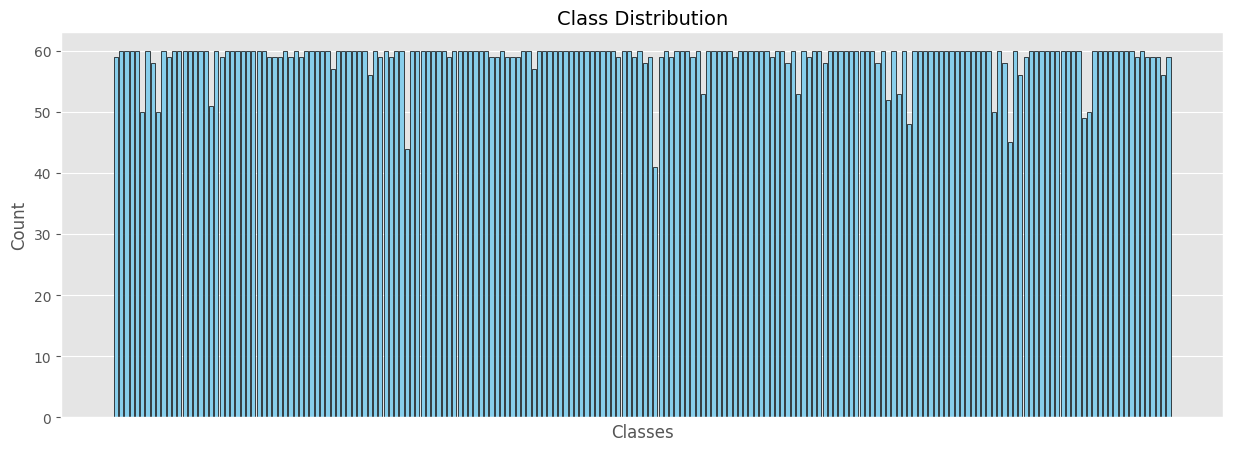

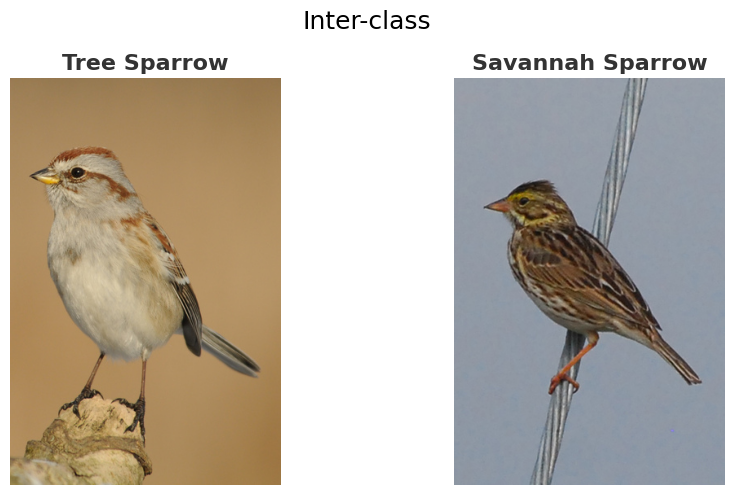

In [26]:
dataset_manager.visualize_dataset()

### Dataset creation

In [27]:
train_dataset, val_dataset, test_dataset = dataset_manager.create_tf_datasets(batch_size=64)

execution_times['Dataset Prep'] = time.time() - step_start
print(f"Completato in {execution_times['Dataset Prep']:.2f} s")

Completato in 91.23 s


### Data augmentation


 Data Augmentation


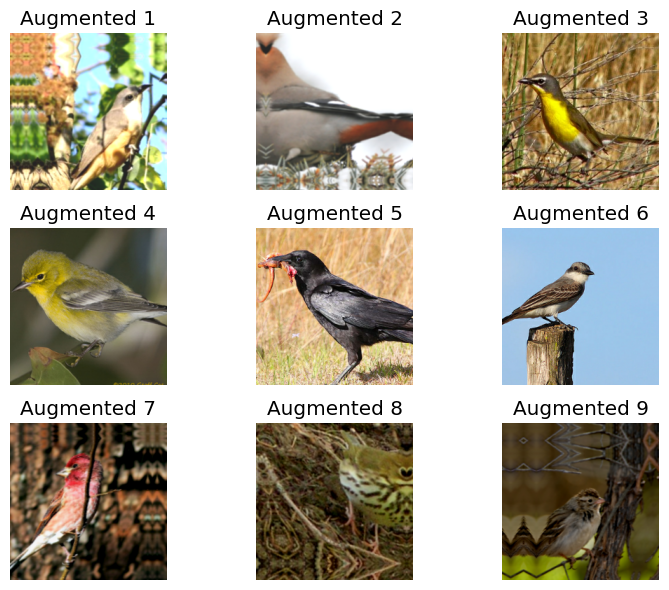

In [28]:
print("\n Data Augmentation")
step_start = time.time()

AugmentationPipeline.show_augmented_samples(train_dataset, num_samples=9)

execution_times['Augmentation Viz'] = time.time() - step_start

## MobileNetV2

In [29]:
print("\n MobileNetV2")
step_start = time.time()

mobilenet = MobileNetV2Model(num_classes=200)
mobilenet.build_model()
mobilenet.train_head(train_dataset, val_dataset, epochs=5, lr=0.01, weight_decay=5e-4)
mobilenet.fine_tune(train_dataset, val_dataset, start_block=15, epochs=100)


 MobileNetV2
9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step

 Training della testa
Epoch 1/5
80/80 ━━━━━━━━━━━━━━━━━━━━ 28s 223ms/step - accuracy: 0.0123 - loss: 5.9865 - top5_acc: 0.0445 - val_accuracy: 0.1689 - val_loss: 4.1313 - val_top5_acc: 0.4133
Epoch 2/5
80/80 ━━━━━━━━━━━━━━━━━━━━ 17s 212ms/step - accuracy: 0.0810 - loss: 4.5362 - top5_acc: 0.2419 - val_accuracy: 0.3044 - val_loss: 3.2306 - val_top5_acc: 0.6178
Epoch 3/5
80/80 ━━━━━━━━━━━━━━━━━━━━ 22s 228ms/step - accuracy: 0.1340 - loss: 3.9631 - top5_acc: 0.3581 - val_accuracy: 0.3622 - val_loss: 2.9430 - val_top5_acc: 0.6822
Epoch 4/5
80/80 ━━━━━━━━━━━━━━━━━━━━ 18s 198ms/step - accuracy: 0.1741 - loss: 3.6190 - top5_acc: 0.4426 - val_accuracy: 0.3856 - val_loss: 2.8590 - val_top5_acc: 0.7144
Epoch 5/5
80/80 ━━━━━━━━━━━━━━━━━━━━ 21s 204ms/step - accuracy: 0.1885 - loss: 3.4995 - top5_acc: 0.4609 - val_accuracy: 0.3867 - val_loss: 2.8566 - val_top5_acc: 0.7222

 Fine-tuning dal blocco 15
Epoch 6/105
80/80 ━━━━━━━━━━━━━━━━━━

In [ ]:
print("\nMobileNetV2 Test Results:")
mobilenet.evaluate(test_dataset)
mobilenet.plot_results("MobileNetV2")

execution_times['MobileNetV2'] = time.time() - step_start
print(f"Completato in {execution_times['MobileNetV2']:.2f} s")

## ResNet50V2

In [30]:
print("\n ResNet50V2")
step_start = time.time()

resnet = ResNet50V2Model(num_classes=200)
resnet.build_model()
resnet.train_head(train_dataset, val_dataset, epochs=5)
resnet.fine_tune(train_dataset, val_dataset, start_stage="conv5", epochs=100)


 ResNet50V2
94668760/94668760 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step

 Training della testa
Epoch 1/5
80/80 ━━━━━━━━━━━━━━━━━━━━ 35s 311ms/step - accuracy: 0.0128 - loss: 5.9442 - top5_acc: 0.0547 - val_accuracy: 0.1844 - val_loss: 3.6519 - val_top5_acc: 0.4456
Epoch 2/5
80/80 ━━━━━━━━━━━━━━━━━━━━ 35s 266ms/step - accuracy: 0.0691 - loss: 4.5971 - top5_acc: 0.2112 - val_accuracy: 0.2900 - val_loss: 3.0350 - val_top5_acc: 0.6278
Epoch 3/5
80/80 ━━━━━━━━━━━━━━━━━━━━ 40s 260ms/step - accuracy: 0.1123 - loss: 4.1004 - top5_acc: 0.3208 - val_accuracy: 0.3578 - val_loss: 2.8322 - val_top5_acc: 0.7022
Epoch 4/5
80/80 ━━━━━━━━━━━━━━━━━━━━ 22s 269ms/step - accuracy: 0.1350 - loss: 3.7588 - top5_acc: 0.3859 - val_accuracy: 0.4000 - val_loss: 2.7860 - val_top5_acc: 0.7322
Epoch 5/5
80/80 ━━━━━━━━━━━━━━━━━━━━ 40s 258ms/step - accuracy: 0.1582 - loss: 3.6219 - top5_acc: 0.4246 - val_accuracy: 0.4056 - val_loss: 2.7987 - val_top5_acc: 0.7378

 Fine-tuning dallo stage conv5
Epoch 6/105
80/80 ━━━━━━━━━━━━━


ResNet50V2 Test Results:
91/91 ━━━━━━━━━━━━━━━━━━━━ 21s 224ms/step - accuracy: 0.7024 - loss: 1.1221 - top5_acc: 0.9254


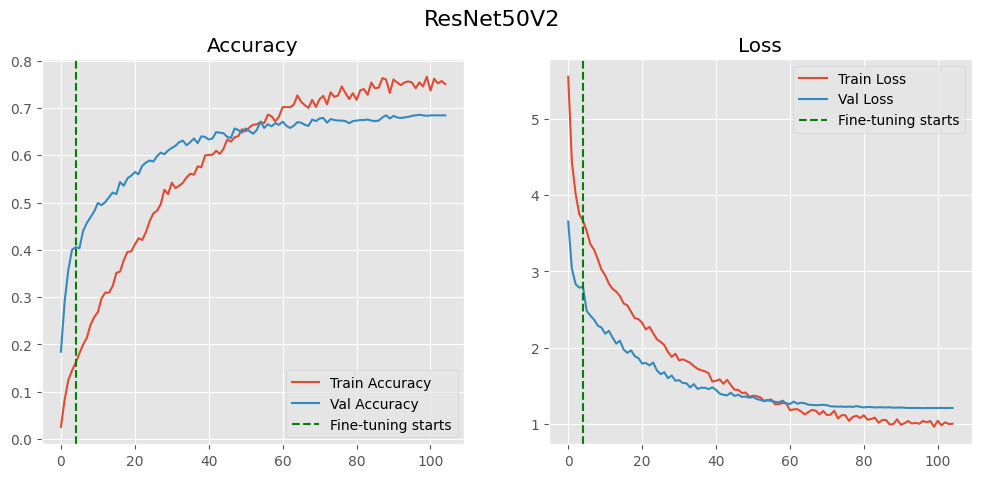

Completato in 3267.51 s


In [31]:
print("\nResNet50V2 Test Results:")
resnet.evaluate(test_dataset)
resnet.plot_results("ResNet50V2")

execution_times['ResNet50V2'] = time.time() - step_start
print(f"Completato in {execution_times['ResNet50V2']:.2f} s")

## InceptionV3

In [32]:
print("\n InceptionV3")
step_start = time.time()

inceptionv3 = InceptionV3Model(num_classes=200, input_shape=(224, 224, 3))
inceptionv3.build_model()
inceptionv3.train_head(train_dataset, val_dataset, epochs=5)
inceptionv3.fine_tune(train_dataset, val_dataset, fine_tune_at="mixed6", epochs=40, alpha=0.05)


 InceptionV3
87910968/87910968 ━━━━━━━━━━━━━━━━━━━━ 6s 0us/step

 Training della testa
Epoch 1/5
80/80 ━━━━━━━━━━━━━━━━━━━━ 46s 427ms/step - accuracy: 0.0176 - loss: 5.8233 - top5_acc: 0.0640 - val_accuracy: 0.1500 - val_loss: 4.1175 - val_top5_acc: 0.3578
Epoch 2/5
80/80 ━━━━━━━━━━━━━━━━━━━━ 27s 341ms/step - accuracy: 0.0987 - loss: 4.3290 - top5_acc: 0.2786 - val_accuracy: 0.2922 - val_loss: 3.2525 - val_top5_acc: 0.6056
Epoch 3/5
80/80 ━━━━━━━━━━━━━━━━━━━━ 28s 344ms/step - accuracy: 0.1393 - loss: 3.8169 - top5_acc: 0.3746 - val_accuracy: 0.3767 - val_loss: 2.9632 - val_top5_acc: 0.6811
Epoch 4/5
80/80 ━━━━━━━━━━━━━━━━━━━━ 41s 346ms/step - accuracy: 0.1808 - loss: 3.5491 - top5_acc: 0.4350 - val_accuracy: 0.3989 - val_loss: 2.8607 - val_top5_acc: 0.7189
Epoch 5/5
80/80 ━━━━━━━━━━━━━━━━━━━━ 28s 347ms/step - accuracy: 0.1925 - loss: 3.4019 - top5_acc: 0.4778 - val_accuracy: 0.4200 - val_loss: 2.8454 - val_top5_acc: 0.7289

 Fine-tuning dal layer mixed6
Epoch 6/45
80/80 ━━━━━━━━━━━━━━


InceptionV3 Test Results:
91/91 ━━━━━━━━━━━━━━━━━━━━ 27s 300ms/step - accuracy: 0.7617 - loss: 0.8841 - top5_acc: 0.9517


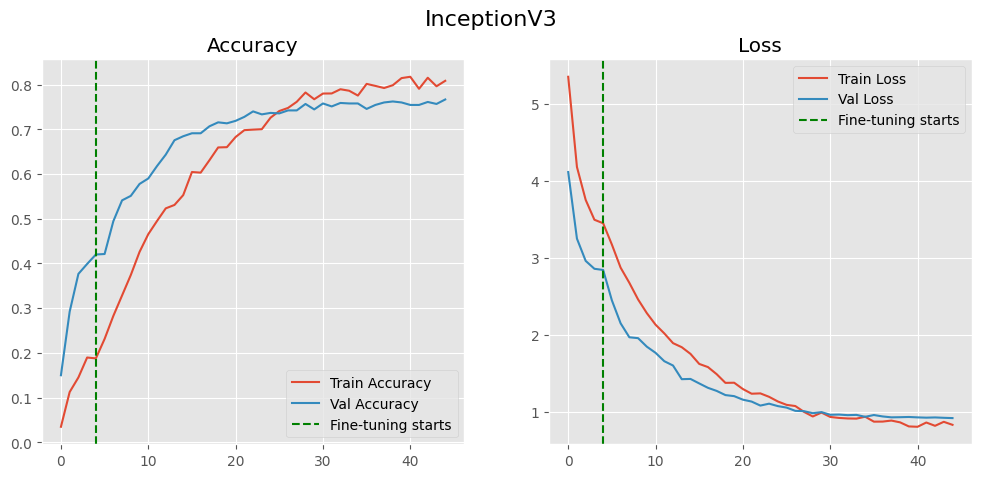

Completato in 1799.76 s


In [33]:
print("\nInceptionV3 Test Results:")
inceptionv3.evaluate(test_dataset)
inceptionv3.plot_results("InceptionV3")

execution_times['InceptionV3'] = time.time() - step_start
print(f"Completato in {execution_times['InceptionV3']:.2f} s")

## CustomCNN

In [34]:
print("\n Custom CNN")

step_start = time.time()
custom_cnn = CustomCNNClassifier(input_shape=(224, 224, 3), num_classes=200)

# Grid search
# custom_cnn.run_grid_search(train_dataset, val_dataset, max_trials=30, epochs_per_trial=20)

custom_cnn.train(train_dataset, val_dataset, epochs=150)


 Custom CNN
Epoch 1/150
80/80 ━━━━━━━━━━━━━━━━━━━━ 44s 422ms/step - accuracy: 0.0055 - loss: 6.4415 - val_accuracy: 0.0056 - val_loss: 5.9932
Epoch 2/150
80/80 ━━━━━━━━━━━━━━━━━━━━ 31s 373ms/step - accuracy: 0.0092 - loss: 5.6837 - val_accuracy: 0.0078 - val_loss: 5.5120
Epoch 3/150
80/80 ━━━━━━━━━━━━━━━━━━━━ 30s 379ms/step - accuracy: 0.0095 - loss: 5.4756 - val_accuracy: 0.0100 - val_loss: 5.5285
Epoch 4/150
80/80 ━━━━━━━━━━━━━━━━━━━━ 30s 374ms/step - accuracy: 0.0116 - loss: 5.3698 - val_accuracy: 0.0078 - val_loss: 5.7413
Epoch 5/150
80/80 ━━━━━━━━━━━━━━━━━━━━ 30s 374ms/step - accuracy: 0.0207 - loss: 5.2907 - val_accuracy: 0.0089 - val_loss: 5.5381
Epoch 6/150
80/80 ━━━━━━━━━━━━━━━━━━━━ 44s 417ms/step - accuracy: 0.0215 - loss: 5.2360 - val_accuracy: 0.0278 - val_loss: 5.2704
Epoch 7/150
80/80 ━━━━━━━━━━━━━━━━━━━━ 31s 379ms/step - accuracy: 0.0262 - loss: 5.2142 - val_accuracy: 0.0289 - val_loss: 5.2356
Epoch 8/150
80/80 ━━━━━━━━━━━━━━━━━━━━ 42s 386ms/step - accuracy: 0.0269 - lo


 Custom CNN Test Results:
91/91 ━━━━━━━━━━━━━━━━━━━━ 16s 173ms/step - accuracy: 0.3308 - loss: 3.5934


<Figure size 640x480 with 0 Axes>

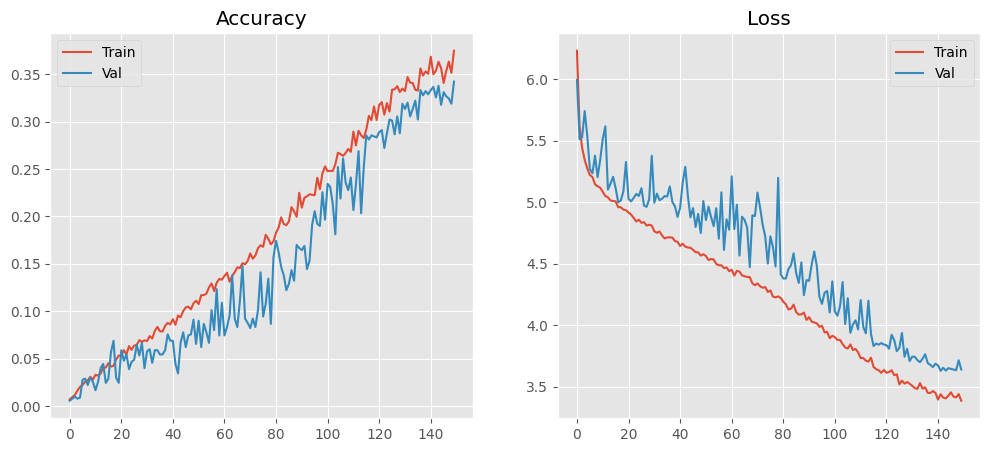

 Completato in 4878.81 s


In [35]:
print("\n Custom CNN Test Results:")
custom_cnn.evaluate(test_dataset)

custom_cnn.plot_results("Custom CNN")

execution_times['Custom CNN'] = time.time() - step_start
print(f" Completato in {execution_times['Custom CNN']:.2f} s")

## Feature extraction (InceptionV3 + SVM)

In [36]:
print("\n InceptionV3 Feature Extraction + SVM")

step_start = time.time()

inception_svm = InceptionSVMClassifier(num_classes=200)
inception_svm.build_feature_extractor()
inception_svm.extract_features(train_dataset, val_dataset, test_dataset)

# SVM grid search
# inception_svm.run_svm_grid_search(cv=3)

inception_svm.train_best_svm(use_calibration=True)


 InceptionV3 Feature Extraction + SVM
Training features shape: (5094, 2048)
Validation features shape: (900, 2048)
Test features shape: (5794, 2048)


In [37]:
inception_svm.evaluate()

execution_times['IncV3 + SVM'] = time.time() - step_start
print(f"Completato in {execution_times['IncV3 + SVM']:.2f} s")



Risultati della SVM
Validation Accuracy: 0.6467
Test Accuracy: 0.6612
              precision    recall  f1-score   support

           0       0.88      0.73      0.80        30
           1       0.85      0.73      0.79        30
           2       0.62      0.93      0.74        28
           3       0.85      0.97      0.91        30
           4       0.69      0.79      0.73        14
           5       1.00      0.82      0.90        11
           6       0.96      0.96      0.96        23
           7       0.65      0.83      0.73        18
           8       0.54      0.24      0.33        29
           9       0.81      0.83      0.82        30
          10       0.56      0.33      0.42        30
          11       0.83      0.77      0.80        26
          12       0.86      0.83      0.85        30
          13       0.79      0.87      0.83        30
          14       0.77      0.82      0.79        28
          15       0.91      0.75      0.82        28
         

## Feature extraction (InceptionV3 + SVM)

In [38]:
print("\n InceptionV3 Fine-Tuned Feature Extraction + SVM")
step_start = time.time()

inceptionfn_svm = InceptionSVMClassifier(model=inceptionv3.base_model, num_classes=200)
inceptionfn_svm.build_feature_extractor()
inceptionfn_svm.extract_features(train_dataset, val_dataset, test_dataset)

# SVM grid search
# inceptionfn_svm.run_svm_grid_search(cv=3)

inceptionfn_svm.train_best_svm(use_calibration=True)


 InceptionV3 Fine-Tuned Feature Extraction + SVM
Training features shape: (5094, 2048)
Validation features shape: (900, 2048)
Test features shape: (5794, 2048)


In [39]:
inceptionfn_svm.evaluate()

execution_times['IncV3 fine-tuned + SVM'] = time.time() - step_start
print(f"Completato in {execution_times['IncV3 fine-tuned + SVM']:.2f} s")



Risultati della SVM
Validation Accuracy: 0.7689
Test Accuracy: 0.7705
              precision    recall  f1-score   support

           0       0.96      0.83      0.89        30
           1       0.88      0.70      0.78        30
           2       0.77      0.96      0.86        28
           3       0.90      0.90      0.90        30
           4       0.80      0.86      0.83        14
           5       1.00      0.82      0.90        11
           6       0.96      0.96      0.96        23
           7       0.72      1.00      0.84        18
           8       0.40      0.34      0.37        29
           9       0.92      0.80      0.86        30
          10       0.60      0.50      0.55        30
          11       0.96      0.92      0.94        26
          12       0.96      0.90      0.93        30
          13       0.90      0.93      0.92        30
          14       0.86      0.89      0.88        28
          15       1.00      0.82      0.90        28
         

# Save models

In [ ]:
print("\n Salvataggio dei modelli")
step_start = time.time()

resnet.model.save_weights("resnet_model.weights.h5")
mobilenet.model.save_weights("mobilenet_model.weights.h5")
inceptionv3.model.save_weights("inceptionv3_model.weights.h5")
custom_cnn.best_model.save_weights("custom_model.weights.h5")

execution_times['Saving Weights'] = time.time() - step_start

# Model comparison

In [40]:
print("\n Valutazione dei modelli")

step_start = time.time()

evaluator = ModelEvaluator(test_dataset)

evaluator.add_model("ResNet50V2", resnet.model, resnet.get_history())
evaluator.add_model("MobileNetV2", mobilenet.model, mobilenet.get_history())
evaluator.add_model("InceptionV3", inceptionv3.model, inceptionv3.get_history())
evaluator.add_model("CustomCNN", custom_cnn.best_model, custom_cnn.get_history())
evaluator.add_model(
     "InceptionV3-SVM",
     inception_svm.svm_model,
     is_sklearn=True,
     feature_extractor=inception_svm.feature_extractor
)
evaluator.add_model(
     "InceptionV3-fine-tuned-SVM",
     inceptionfn_svm.svm_model,
     is_sklearn=True,
     feature_extractor=inceptionfn_svm.feature_extractor
)


 Valutazione dei modelli
Model ResNet50V2 added successfully!
Model MobileNetV2 added successfully!
Model InceptionV3 added successfully!
Model CustomCNN added successfully!
Extracting features using InceptionV3_FeatureExtractor...
Model InceptionV3-SVM added successfully!
Extracting features using InceptionV3_FeatureExtractor...
Model InceptionV3-fine-tuned-SVM added successfully!


## Loss and Accuracy plots

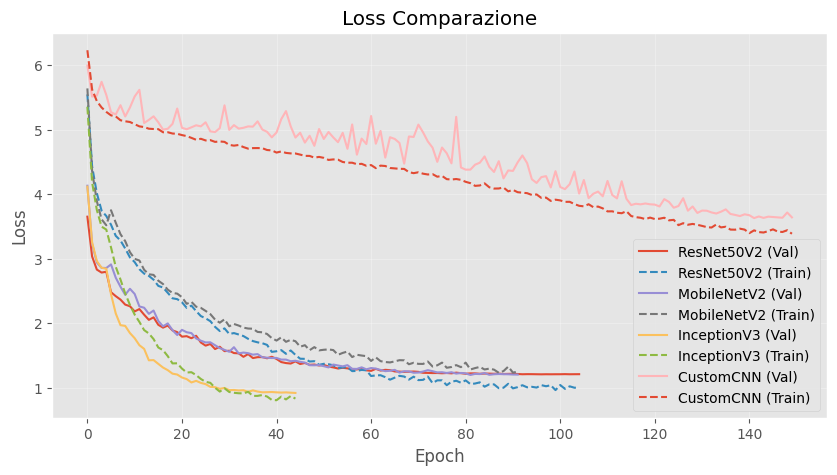

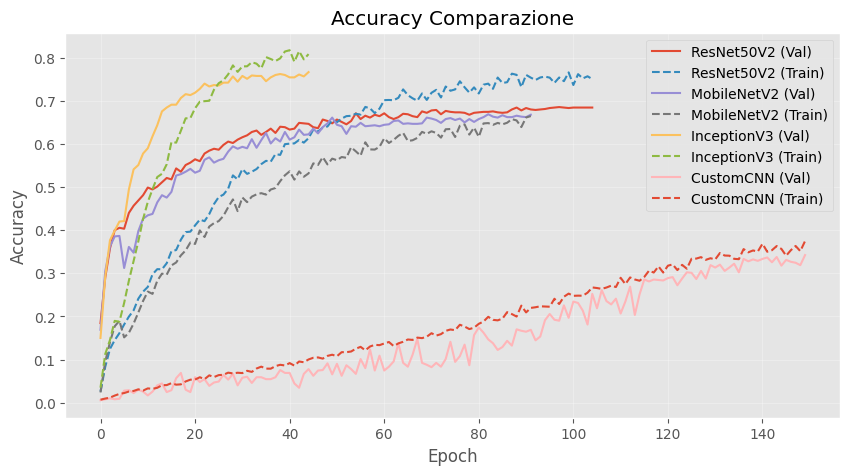

In [41]:
evaluator.plot_training_comparison(metric='loss')
evaluator.plot_training_comparison(metric='accuracy')

## Classification Report

In [42]:
evaluator.print_classification_reports()


-------------------- Model: ResNet50V2 --------------------
              precision    recall  f1-score   support

           0      0.815     0.733     0.772        30
           1      0.720     0.600     0.655        30
           2      0.667     0.857     0.750        28
           3      0.771     0.900     0.831        30
           4      0.625     0.714     0.667        14
           5      0.818     0.818     0.818        11
           6      0.840     0.913     0.875        23
           7      0.652     0.833     0.732        18
           8      0.545     0.414     0.471        29
           9      0.833     0.833     0.833        30
          10      0.455     0.500     0.476        30
          11      1.000     0.923     0.960        26
          12      0.867     0.867     0.867        30
          13      0.793     0.767     0.780        30
          14      0.806     0.893     0.847        28
          15      1.000     0.821     0.902        28
          16      0.

## ROC curve e PR curve

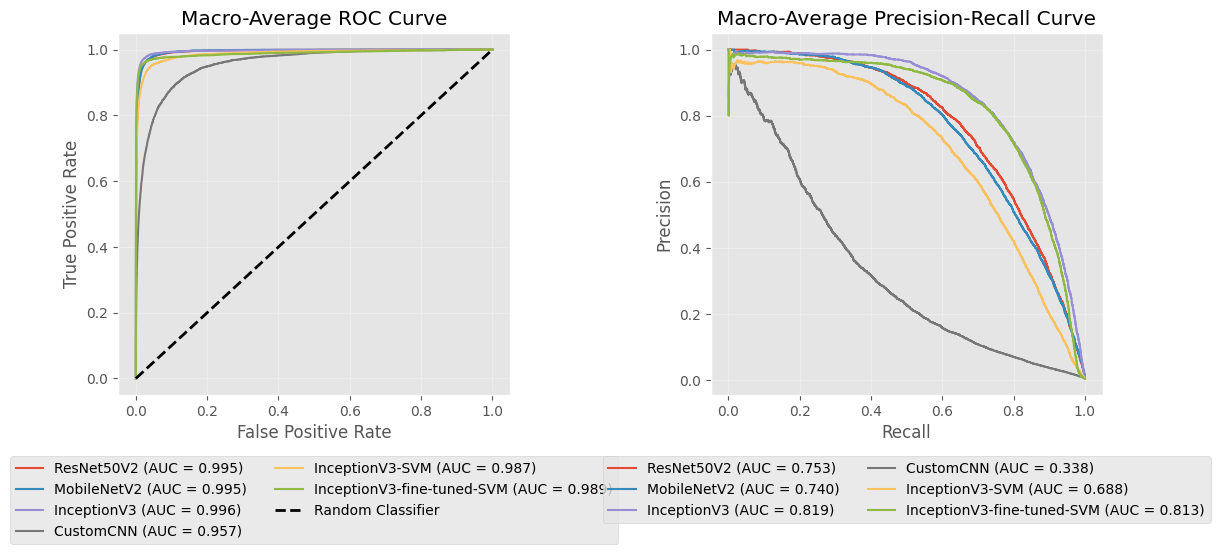

In [43]:
evaluator.plot_roc_pr_micro()

## Calibration curve

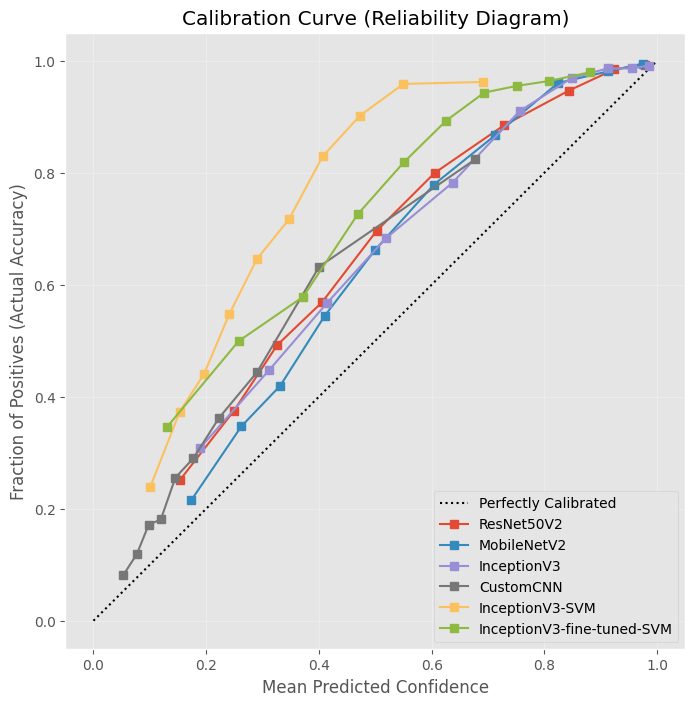

In [44]:
evaluator.plot_calibration()

## Radar summary

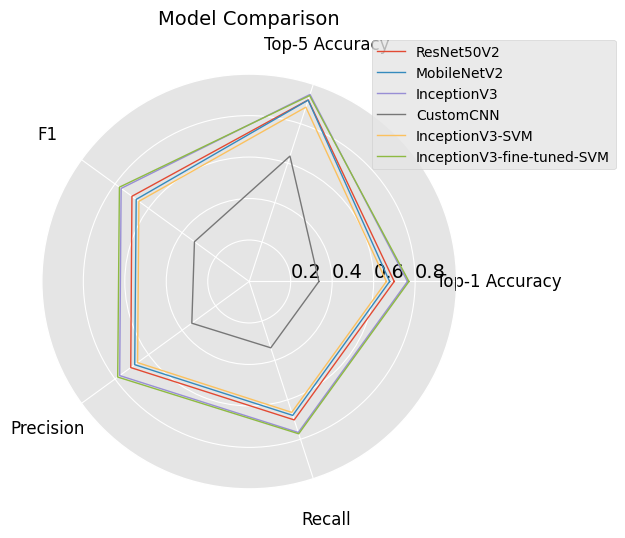

In [45]:
evaluator.plot_radar_summary()

## Times

In [46]:
execution_times['Evaluation'] = time.time() - step_start

total_time_script = time.time() - global_start_time

print("\n" + "="*65)
print(f"{'Tempi di esecuzione':^65}")
print("="*65)
print(f"{'Fase':<30} | {'Sec':>10} | {'Min':>10}")
print("-" * 65)

for fase, secondi in execution_times.items():
    if secondi > 0.1:
        minuti = secondi / 60
        print(f"{fase:<30} | {secondi:>10.2f} | {minuti:>10.2f}")

print("-" * 65)
print(f"{'Tempo totale':<30} | {total_time_script:>10.2f} | {total_time_script/60:>10.2f}")
print("="*65)


                       Tempi di esecuzione                       
Fase                           |        Sec |        Min
-----------------------------------------------------------------
Dataset Prep                   |      91.23 |       1.52
Augmentation Viz               |       7.10 |       0.12
ResNet50V2                     |    3267.51 |      54.46
InceptionV3                    |    1799.76 |      30.00
Custom CNN                     |    4878.81 |      81.31
IncV3 + SVM                    |     543.86 |       9.06
IncV3 fine-tuned + SVM         |     324.12 |       5.40
Evaluation                     |     218.67 |       3.64
-----------------------------------------------------------------
Tempo totale                   |   12852.27 |     214.20


In [ ]:
import os
from IPython.display import FileLink

files = [
    "mobilenet_model.weights.h5",
    "inceptionv3_model.weights.h5",
    "custom_model.weights.h5",
    "resnet_model.weights.h5"
]

for f in files:
    if os.path.exists(f):
        print(f"\n File trovato: {f}")
        display(FileLink(f))